#### Salary in Data Science

What can we learn from this dataset? 

Downloaded from [here](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023) this dataset contains multiple descriptive features of the annual salary capturing jobs in the US, in Europe and several countries in asia.

Let's explore a little to find out more about it.

In [104]:
import pandas as pd
import numpy as np

In [105]:
df = pd.read_csv('ds_salaries.csv')
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,3755.000000,3.755000e+03,3755.000000,3755.000000
mean,2022.373635,1.906956e+05,137570.389880,46.271638
std,0.691448,6.716765e+05,63055.625278,48.589050
min,2020.000000,6.000000e+03,5132.000000,0.000000
25%,2022.000000,1.000000e+05,95000.000000,0.000000
50%,2022.000000,1.380000e+05,135000.000000,0.000000
75%,2023.000000,1.800000e+05,175000.000000,100.000000
max,2023.000000,3.040000e+07,450000.000000,100.000000


First problem: there are multiple currencies representing a different value as salary. 
Lucky enough, the authors already provided a comparable value in 'salary_in_usd'. We go by this and use salary_currency as regional marker.

In [106]:
df.groupby('salary_currency').size()

salary_currency
AUD       9
BRL       6
CAD      25
CHF       4
CLP       1
CZK       1
DKK       3
EUR     236
GBP     161
HKD       1
HUF       3
ILS       1
INR      60
JPY       3
MXN       1
PLN       5
SGD       6
THB       2
TRY       3
USD    3224
dtype: int64

In [107]:
# to get a concise understanding of this, we need to group certai currenncies together
# lets group everything below 25

# --> AUD = australia dollar,
# USD = us,
# EUR = euro,
# CAD = canadian dollar,
# GBP = british pound,
# BRL = brazilian real,
# CHF = swiss franc,
# CLP = chilean peso,
# CZK = czech koruna,
# DKK = danish krone, 
# HKD = hong kong dollar,
# HUF = forint (hungary), 
# ILS = israeli shekel,
# INR = indian rupia, 
# JPY = japanese yen, 
# MXN = mexican peso, 
# PLN = polish zloty, 
# SGD = singapur dollar, 
# THB = bath (thai), 
# TRY = turkey lira

# resulting regions are hence: latin america, europe, near east, asia, australia

df['currency_region'] = df.replace({'salary_currency': {'USD': 'us', 'CAD': 'canada', 'GBP': 'britain', 'EUR': 'europe' ,'AUD': 'australia', 'BRL': 'latin america', 'CHF': 'europe', 'CLP': 'latin america', 'CZK': 'europe', 'DKK': 'europe', 'HKD': 'northern asia', 'HUF': 'europe', 'ILS': 'near east', 'JPY': 'northern asia', 'INR': 'south asia', 'MXN': 'latin america', 'PLN': 'europe', 'SGD': 'northern asia', 'THB': 'south asia', 'TRY': 'near east'}})['salary_currency']

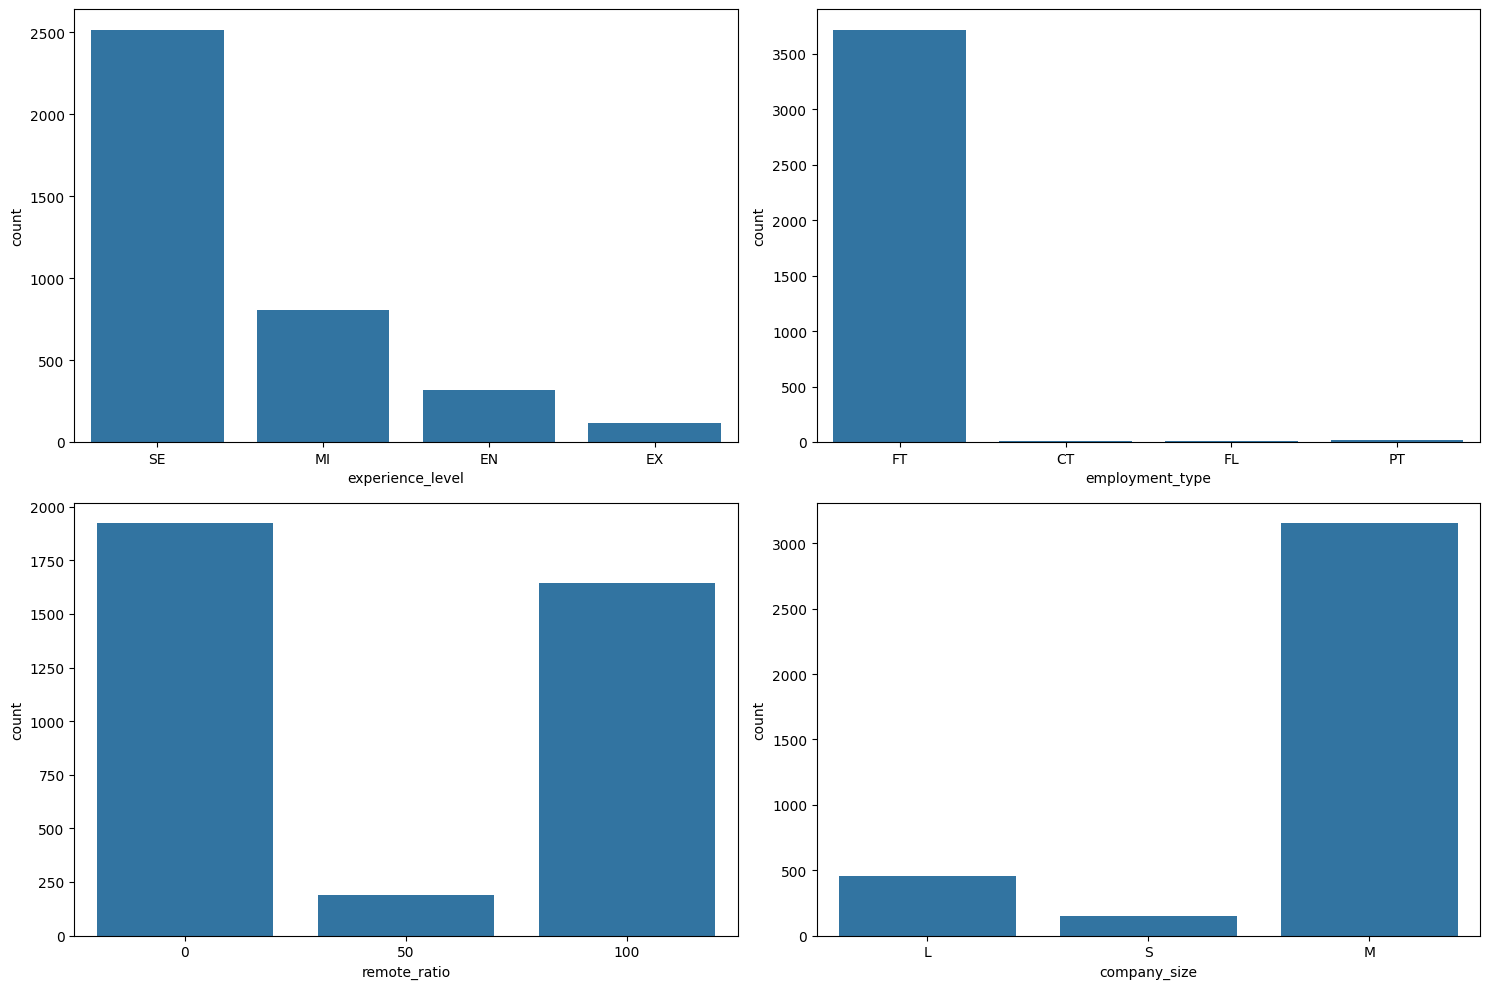

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

# lets explore categorical variables: experience, employment_type, remote_ratio, company_size (ordinal)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
vars = ['experience_level', 'employment_type', 'remote_ratio', 'company_size']
for i, var in enumerate(vars):
    row, col = divmod(i, 2)
    sns.countplot(x=var, data=df, ax=axs[row, col])
plt.tight_layout()
plt.show()


The experience level contains mostly employees of the level 'senior', while there are some 'middle-experienced' workers, few at entry level and just a hundred experts. 

The type of employment contains almost only full time employees. There is not much to gain from this variable.

The remote ratio focuses on either 0% remote work or 100% remote work with moderately many hybrid contracts.

Moreover, the company size is rather unbalanced tending to contain dominantly middle-sized enterprises.


When observing results about 1, 3 or 4, the prior ratio has to be used in order to normalize/balance that result.

In [109]:
# now nominal variables: region, job_title, work_year, salary_currency, employee_residence, company_location
print("Number of items for each Category:")
vars = ['currency_region', 'job_title', 'work_year', 'salary_currency', 'employee_residence', 'company_location']
for i in vars:
    print(f"Job: {i} and count: {df[i].nunique()}")

Number of items for each Category:
Job: currency_region and count: 9
Job: job_title and count: 93
Job: work_year and count: 4
Job: salary_currency and count: 20
Job: employee_residence and count: 78
Job: company_location and count: 72


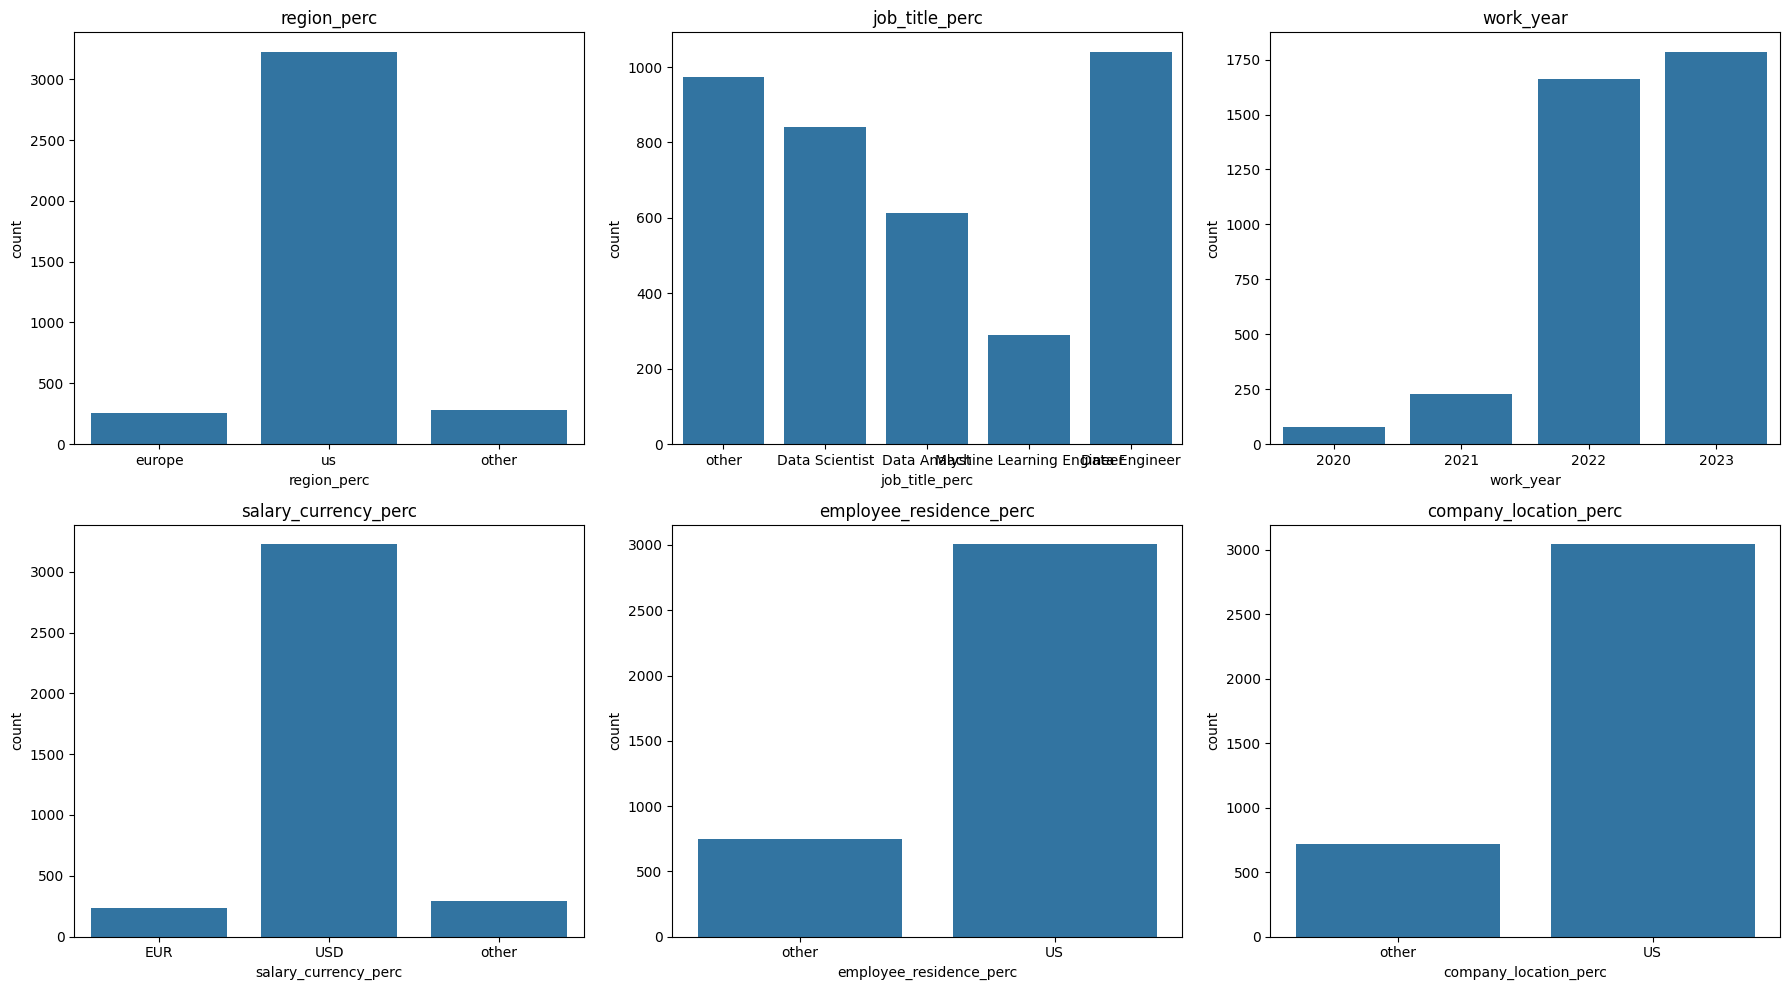

In [110]:
# even 20 is too much --> proceed by grouping according to percentage

df['company_location_perc'] = np.where(df['company_location'].map(df['company_location'].value_counts(normalize=True)) < 0.05, 'other', df['company_location'])
df['region_perc'] = np.where(df['currency_region'].map(df['currency_region'].value_counts(normalize=True)) < 0.05, 'other', df['currency_region'])
vars = ['region_perc', 'job_title_perc', 'work_year', 'salary_currency_perc', 'employee_residence_perc', 'company_location_perc']
df['job_title_perc'] = np.where(df['job_title'].map(df['job_title'].value_counts(normalize=True)) < 0.05, 'other', df['job_title'])
df['salary_currency_perc'] = np.where(df['salary_currency'].map(df['salary_currency'].value_counts(normalize=True)) < 0.05, 'other', df['salary_currency'])
df['employee_residence_perc'] = np.where(df['employee_residence'].map(df['employee_residence'].value_counts(normalize=True))< 0.05, 'other', df['employee_residence'])

fig, axs = plt.subplots(2,3, figsize=(18, 10))
vars = ['region_perc', 'job_title_perc', 'work_year', 'salary_currency_perc', 'employee_residence_perc', 'company_location_perc']

for i, var in enumerate(vars):
    row, col = divmod(i, 3)
    axs[row, col].set_title(var)
    sns.countplot(x=var, data=df, ax=axs[row, col])

plt.tight_layout()
plt.show()

#### Hypothesis

Rather than looking for a finding, testing hypotheses may be more enlightening and straightforward.

After consulting with a chatbot that shall not be mentioned, the resulting set seems promising and will be tested for:

Location Hypothesis: The location of residence does not significantly affect the salary, but the location of the company does.

Factors that influence salary are (1) the level of experience represented by certain words in the (2) job title.

The work year is an indicator of the demand for data science jobs, having a positive effect on the expected salary.

The type of employment separates the salary into clearly discernible groups.

The interplay of remote work, salary currency, and employee residence carries information likely predictive of the salary for the majority of this subpopulation for certain regions.

----

*Let's start with those and see where this arrives.*

In [111]:
df = df.drop(['company_location_perc', 'region_perc', 'job_title_perc',
       'salary_currency_perc', 'employee_residence_perc', 'salary_currency'], axis=1)


# define a function that applies 'other' for too little categorical data points

def adjust_categories(df, column, threshold=0.01):
    counts = df[column].value_counts(normalize=True)
    df[f'{column}'] = np.where(df[column].map(counts) < threshold, 'other', df[column])

    return df

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
for column in categorical_columns:
    df = adjust_categories(df, column)


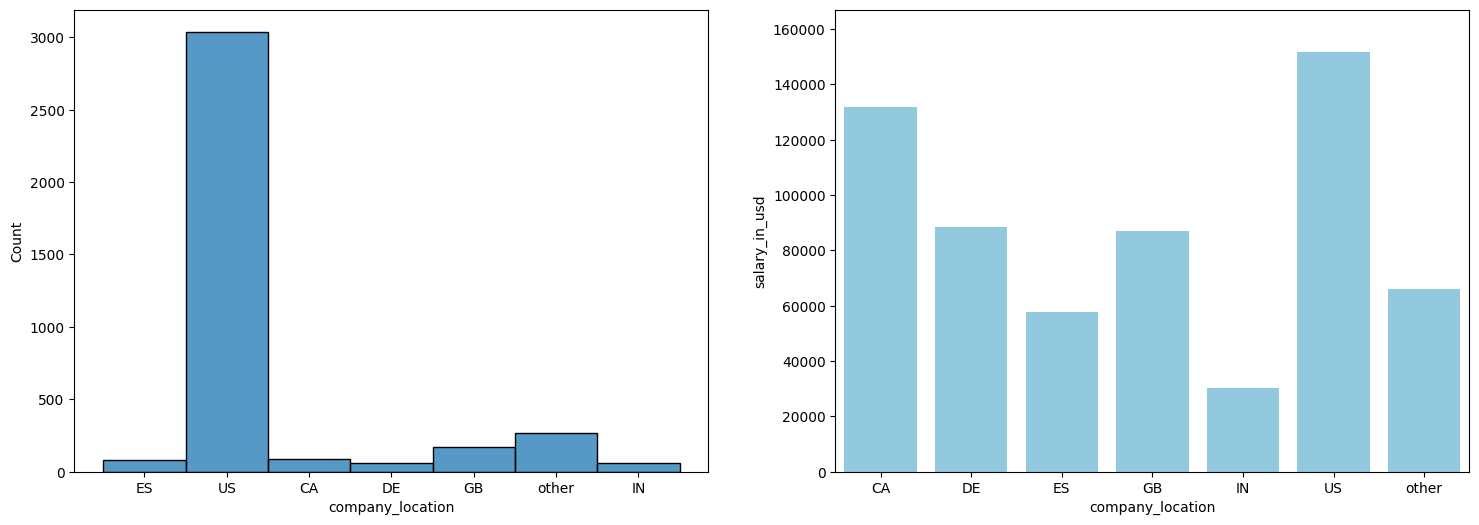

In [112]:
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Histogram of company_location_adjusted
sns.histplot(df['company_location'], ax=axs[0])

# Plot 2: Mean salary by company_location_adjusted
mean_salary_by_location = df.groupby('company_location')['salary_in_usd'].mean().reset_index()
sns.barplot(x='company_location', y='salary_in_usd', data=mean_salary_by_location, ax=axs[1], color='skyblue')
axs[1].set_ylim(0, mean_salary_by_location['salary_in_usd'].max() * 1.1)

plt.show()

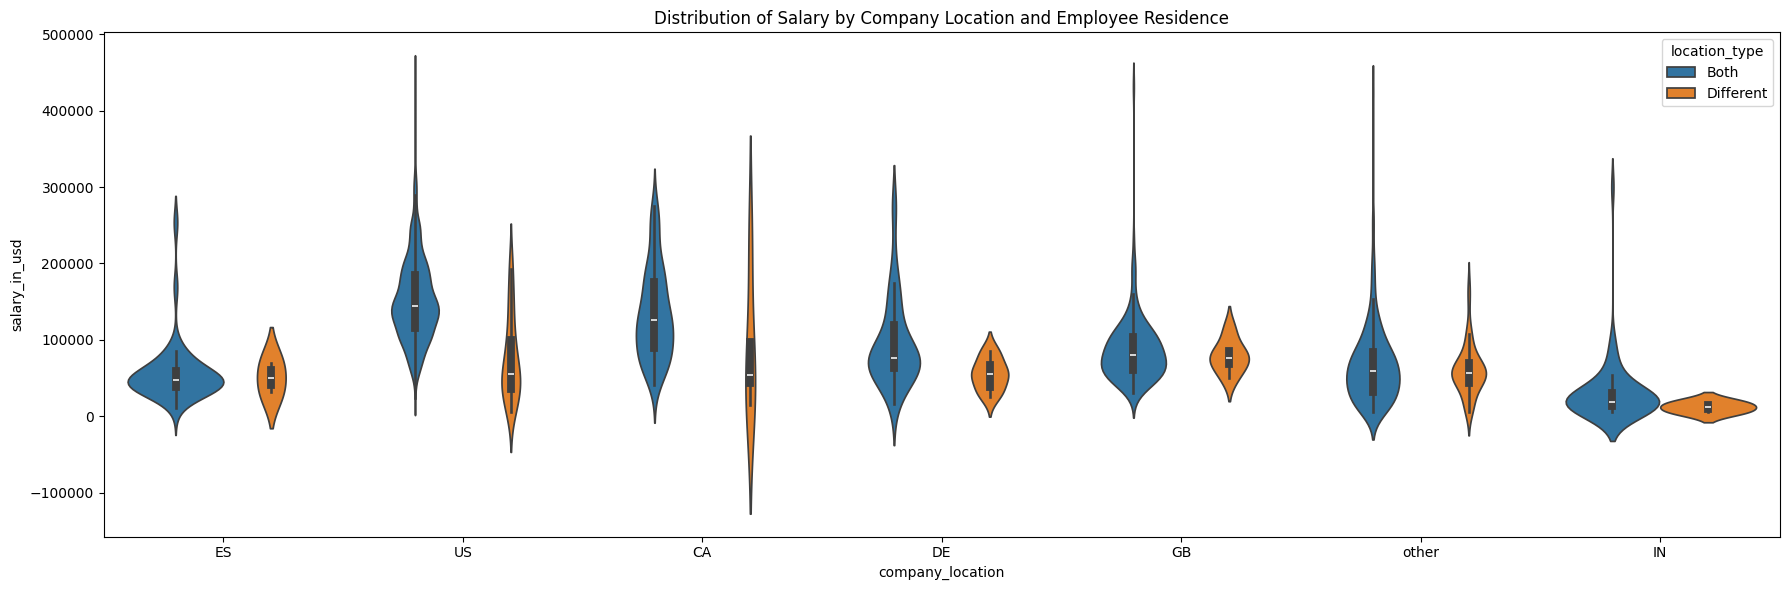

In [113]:
fig, ax = plt.subplots(figsize=(18, 6))

# Combine company_location and employee_residence into a single column for hue
df['location_type'] = np.where(df['company_location'] == df['employee_residence'], 'Both', 'Different')

# Plot the violin plot with hue
sns.violinplot(x='company_location', y='salary_in_usd', hue='location_type', data=df, split=False, ax=ax)
ax.set_title('Distribution of Salary by Company Location and Employee Residence')

plt.tight_layout()
plt.show()


It is quite visible that many companies tend to pay employees in the same country more than those in foreign countries (with the exception of canada).



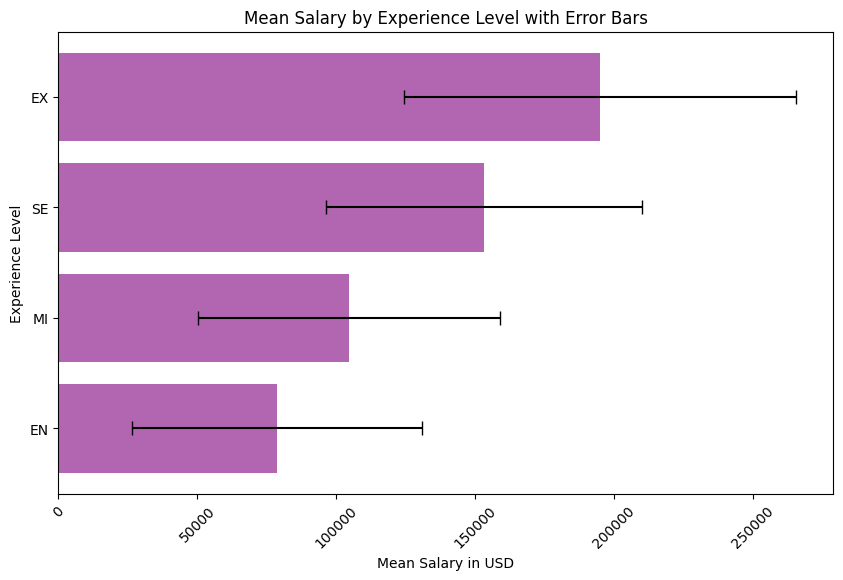

In [114]:
# experience level

# Calculate means and standard deviations
means = df.groupby('experience_level')['salary_in_usd'].mean().sort_values(ascending=True)
stds = df.groupby('experience_level')['salary_in_usd'].std().sort_values(ascending=True)

# Plot with error bars
plt.figure(figsize=(10, 6))
plt.barh(y=means.index, width=means, xerr=stds, capsize=5, color='purple', alpha=0.6)
plt.title('Mean Salary by Experience Level with Error Bars')
plt.xlabel('Mean Salary in USD')
plt.ylabel('Experience Level')

# Rotate the x-axis labels
plt.xticks(rotation=45)

plt.show()

In [115]:
# job title

df.job_title.value_counts()

job_title
Data Engineer                1040
Data Scientist                840
Data Analyst                  612
other                         572
Machine Learning Engineer     289
Analytics Engineer            103
Data Architect                101
Research Scientist             82
Applied Scientist              58
Data Science Manager           58
Name: count, dtype: int64

In [116]:
# extract most common terms
most_freq_terms = df.job_title.str.extractall(r'(\b\w+\b)').value_counts().head()
most_freq_terms

Data         2651
Engineer     1432
Scientist     980
Analyst       612
other         572
Name: count, dtype: int64

In [117]:
# use these terms to find significant overlap with the payments (salary_in_usd) or the experience level

# Count the number of term occurrences in the highest experience_level
highest_experience_level = df['experience_level'].value_counts().idxmax()
term_counts = {}

for term in most_freq_terms.index:
    term_counts[term[0]] = df[df['experience_level'] == highest_experience_level]['job_title'].str.contains(term[0], case=False).sum()

# Convert term counts to percentages
total_highest_experience = df[df['experience_level'] == highest_experience_level].shape[0]
# Iterate over all experience levels
for level in df['experience_level'].unique():
    print(f"Processing experience level: {level}")
    
    # Count the number of term occurrences in the current experience level
    term_counts = {}
    for term in most_freq_terms.index:
        term_counts[term[0]] = df[df['experience_level'] == level]['job_title'].str.contains(term[0], case=False).sum()
    
    # Convert term counts to percentages
    total_experience = df[df['experience_level'] == level].shape[0]
    term_percentages = {term: (count / total_experience) * 100 for term, count in term_counts.items()}
    
    # Reorder experience levels
    experience_order = ['EX', 'SE', 'MI', 'EN']
    term_percentages = {term: term_percentages[term] for term in experience_order if term in term_percentages}
    term_percentages = {term: (count / total_experience) * 100 for term, count in term_counts.items()}
    
    print(term_percentages)



# Define salary bins
salary_bins = pd.cut(df['salary_in_usd'], bins=[0, 50000, 100000, 150000, 200000, 250000, 300000, 350000, 400000, 450000, 500000, np.inf], labels=['0-50k', '50-100k', '100-150k', '150-200k', '200-250k', '250-300k', '300-350k', '350-400k', '400-450k', '450-500k', '500k+'])

# Add the salary bins to the dataframe
df['salary_bin'] = salary_bins

# Iterate over all salary bins
for bin in df['salary_bin'].unique():
    print(f"Processing salary bin: {bin}")
    
    # Count the number of term occurrences in the current salary bin
    term_counts = {}
    for term in most_freq_terms.index:
        term_counts[term[0]] = df[df['salary_bin'] == bin]['job_title'].str.contains(term[0], case=False).sum()
    
    # Convert term counts to percentages
    total_in_bin = df[df['salary_bin'] == bin].shape[0]
    term_percentages = {term: (count / total_in_bin) * 100 for term, count in term_counts.items()}
    
    print(term_percentages)


Processing experience level: SE
{'Data': 73.25119236883943, 'Engineer': 40.06359300476948, 'Scientist': 28.17965023847377, 'Analyst': 15.103338632750399, 'other': 11.208267090620032}
Processing experience level: MI
{'Data': 68.07453416149069, 'Engineer': 34.40993788819876, 'Scientist': 22.857142857142858, 'Analyst': 20.74534161490683, 'other': 20.124223602484474}
Processing experience level: EN
{'Data': 58.75, 'Engineer': 27.500000000000004, 'Scientist': 23.125, 'Analyst': 19.6875, 'other': 29.6875}
Processing experience level: EX
{'Data': 63.1578947368421, 'Engineer': 51.75438596491229, 'Scientist': 11.403508771929824, 'Analyst': 1.7543859649122806, 'other': 28.947368421052634}
Processing salary bin: 50-100k
{'Data': 73.22540473225405, 'Engineer': 33.25031133250312, 'Scientist': 18.43088418430884, 'Analyst': 28.6425902864259, 'other': 18.43088418430884}
Processing salary bin: 0-50k
{'Data': 59.58188153310105, 'Engineer': 20.557491289198605, 'Scientist': 28.57142857142857, 'Analyst': 1

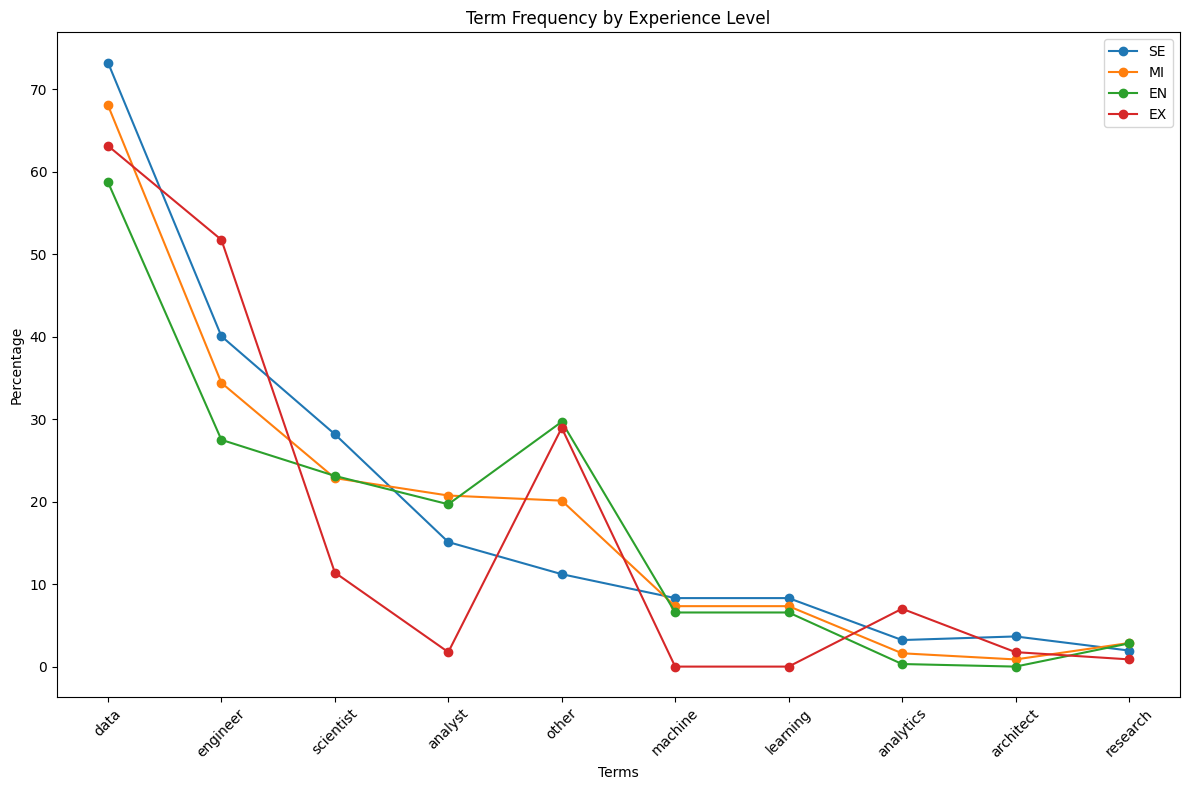

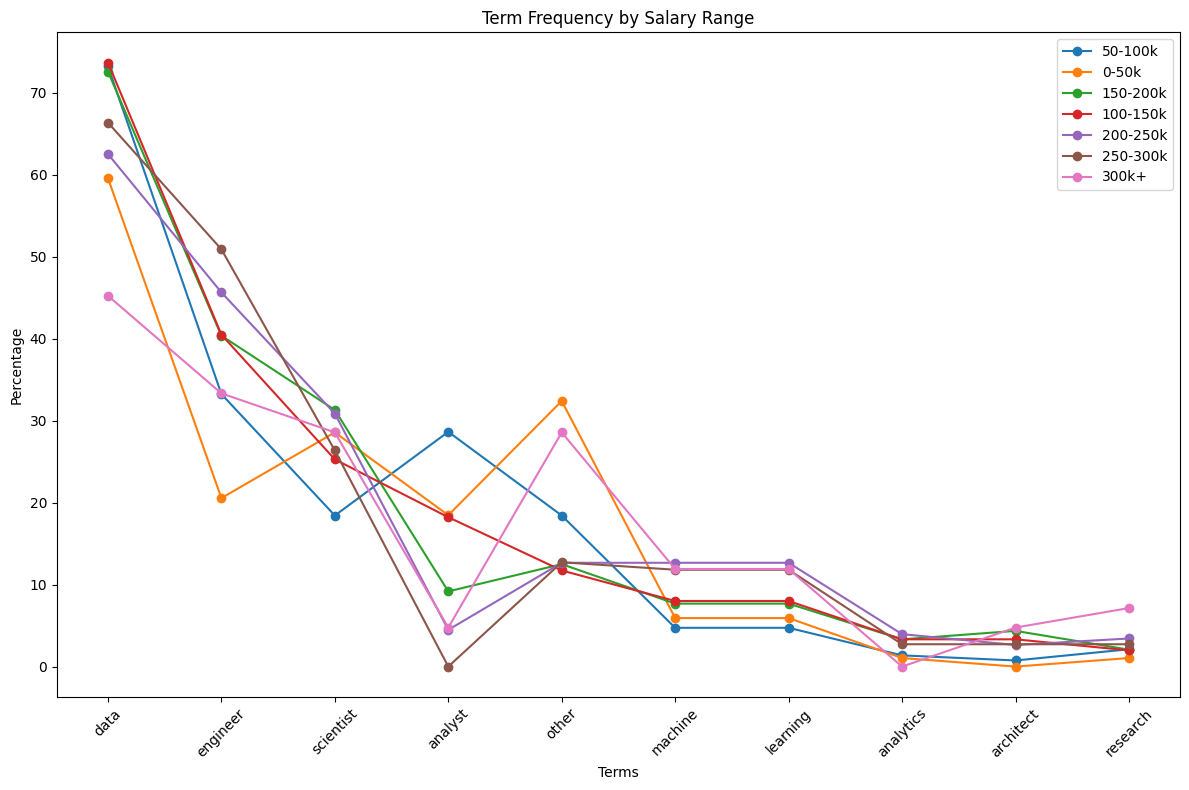

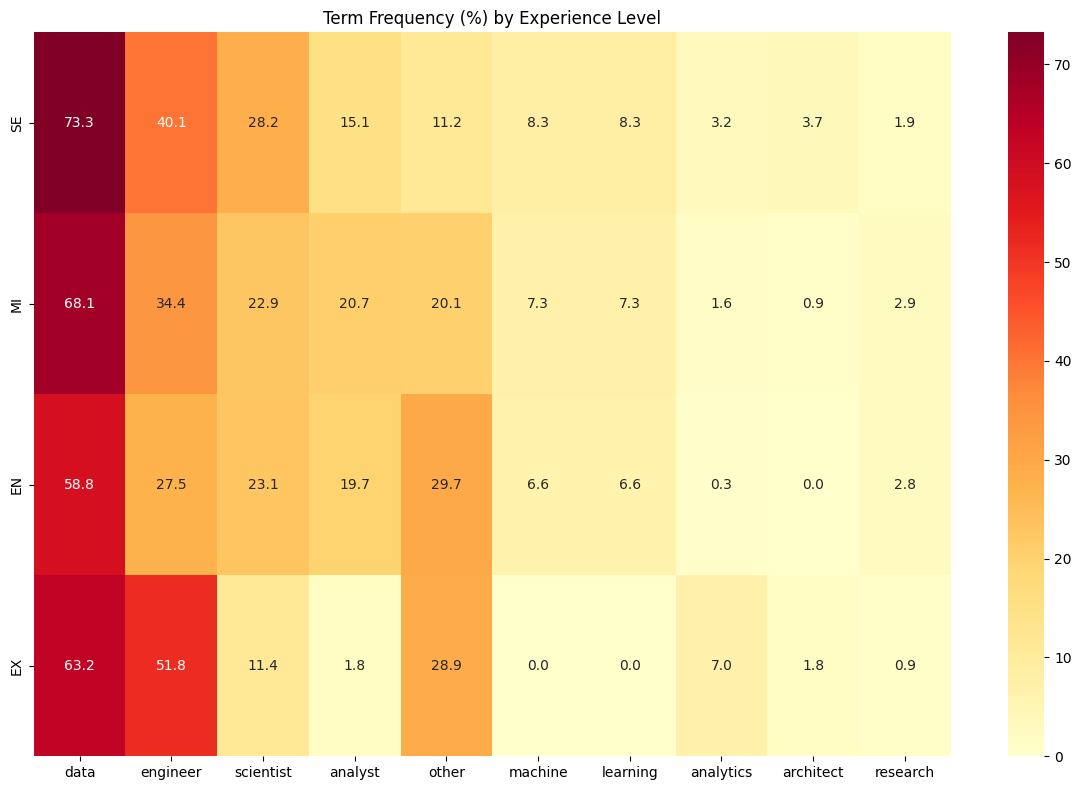

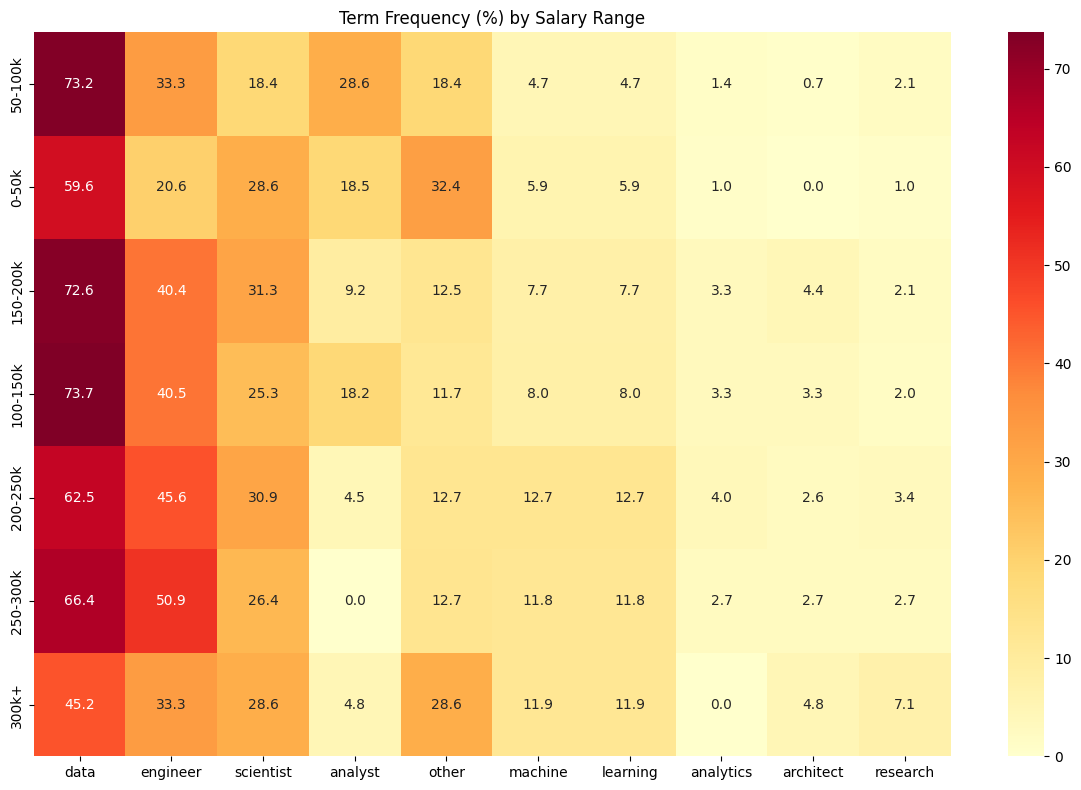

Term frequency by experience level:
         data   engineer  scientist    analyst      other   machine  learning  \
SE  73.251192  40.063593  28.179650  15.103339  11.208267  8.306836  8.306836   
MI  68.074534  34.409938  22.857143  20.745342  20.124224  7.329193  7.329193   
EN  58.750000  27.500000  23.125000  19.687500  29.687500  6.562500  6.562500   
EX  63.157895  51.754386  11.403509   1.754386  28.947368  0.000000  0.000000   

    analytics  architect  research  
SE   3.219396   3.656598  1.947536  
MI   1.614907   0.869565  2.857143  
EN   0.312500   0.000000  2.812500  
EX   7.017544   1.754386  0.877193  

Term frequency by salary range:
               data   engineer  scientist    analyst      other    machine  \
50-100k   73.225405  33.250311  18.430884  28.642590  18.430884   4.732254   
0-50k     59.581882  20.557491  28.571429  18.466899  32.404181   5.923345   
150-200k  72.591743  40.366972  31.307339   9.174312  12.500000   7.683486   
100-150k  73.692552  40.4912

In [118]:
# Find most frequent terms
from collections import Counter

def get_most_frequent_terms(df, column='job_title', n=10):
    all_words = ' '.join(df[column]).lower().split()
    return pd.Series(dict(Counter(all_words).most_common(n)))

most_freq_terms = get_most_frequent_terms(df)

# Function to calculate term percentages for a given subset of data
def calculate_term_percentages(subset_df):
    term_counts = {}
    for term in most_freq_terms.index:
        term_counts[term] = subset_df['job_title'].str.contains(term, case=False).sum()
    total_count = len(subset_df)
    return {term: (count / total_count) * 100 for term, count in term_counts.items()}

# Analyze terms by experience level
experience_term_percentages = {}
for level in df['experience_level'].unique():
    subset = df[df['experience_level'] == level]
    experience_term_percentages[level] = calculate_term_percentages(subset)

# Visualize terms by experience level
plt.figure(figsize=(12, 8))
for level, percentages in experience_term_percentages.items():
    plt.plot(percentages.keys(), percentages.values(), label=level, marker='o')
plt.title('Term Frequency by Experience Level')
plt.xlabel('Terms')
plt.ylabel('Percentage')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Define salary bins
salary_bins = pd.cut(df['salary_in_usd'], 
                     bins=[0, 50000, 100000, 150000, 200000, 250000, 300000, np.inf], 
                     labels=['0-50k', '50-100k', '100-150k', '150-200k', '200-250k', '250-300k', '300k+'])
df['salary_bin'] = salary_bins

# Analyze terms by salary bin
salary_term_percentages = {}
for bin in df['salary_bin'].unique():
    subset = df[df['salary_bin'] == bin]
    salary_term_percentages[bin] = calculate_term_percentages(subset)

# Visualize terms by salary bin
plt.figure(figsize=(12, 8))
for bin, percentages in salary_term_percentages.items():
    plt.plot(percentages.keys(), percentages.values(), label=bin, marker='o')
plt.title('Term Frequency by Salary Range')
plt.xlabel('Terms')
plt.ylabel('Percentage')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Heatmap of term frequency by experience level
term_exp_matrix = pd.DataFrame(experience_term_percentages).T
plt.figure(figsize=(12, 8))
sns.heatmap(term_exp_matrix, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Term Frequency (%) by Experience Level')
plt.tight_layout()
plt.show()

# Heatmap of term frequency by salary bin
term_salary_matrix = pd.DataFrame(salary_term_percentages).T
plt.figure(figsize=(12, 8))
sns.heatmap(term_salary_matrix, annot=True, cmap='YlOrRd', fmt='.1f')
plt.title('Term Frequency (%) by Salary Range')
plt.tight_layout()
plt.show()

# Print summary statistics
print("Term frequency by experience level:")
print(term_exp_matrix)
print("\nTerm frequency by salary range:")
print(term_salary_matrix)

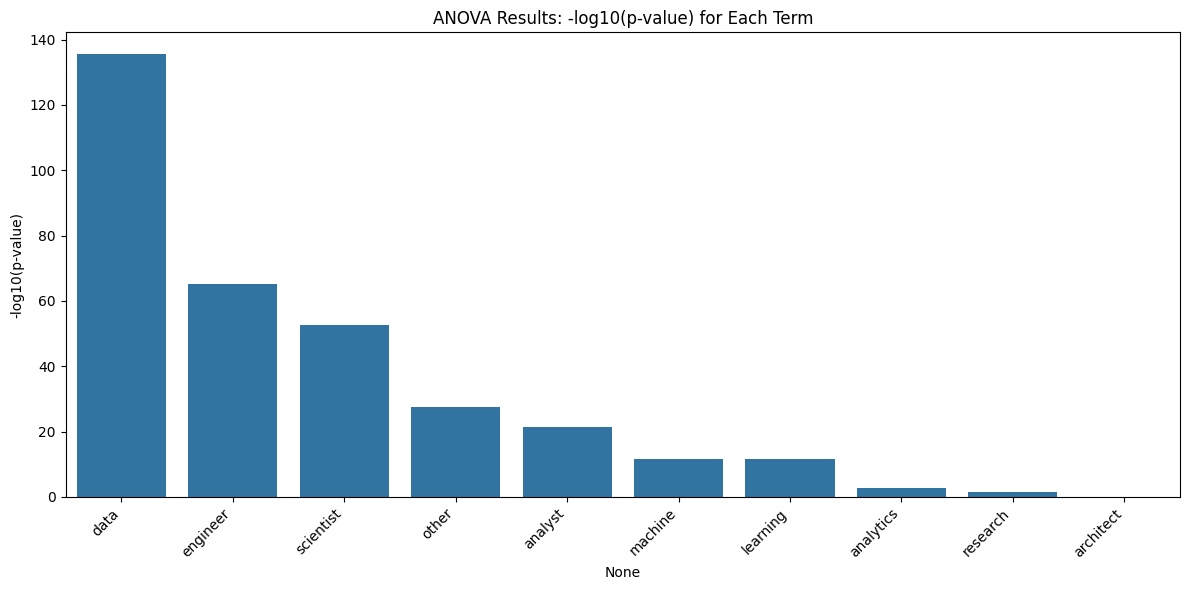

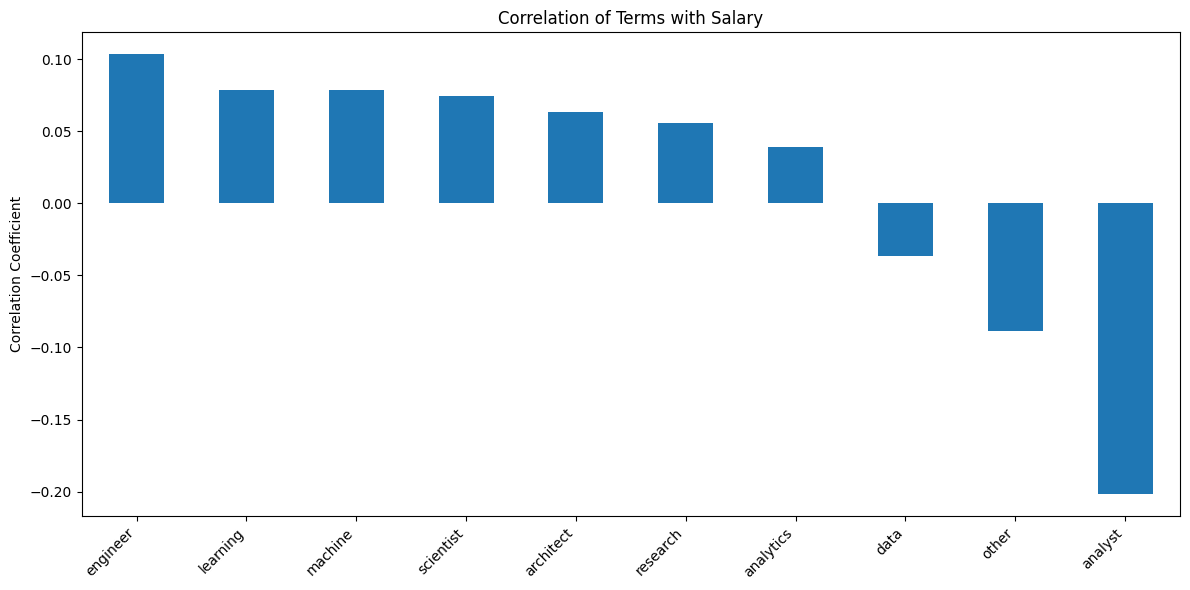

                            OLS Regression Results                            
Dep. Variable:          salary_in_usd   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.077
Method:                 Least Squares   F-statistic:                     35.96
Date:                Thu, 10 Oct 2024   Prob (F-statistic):           1.43e-61
Time:                        18:45:57   Log-Likelihood:                -46671.
No. Observations:                3755   AIC:                         9.336e+04
Df Residuals:                    3745   BIC:                         9.343e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.407e+05   1.14e+04     21.038      0.0

In [119]:
# Previous code cells remain the same

# New cell for advanced analysis
import scipy.stats as stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Function to perform one-way ANOVA
def perform_anova(df, term, target):
    groups = [group[target].values for name, group in df[df['job_title'].str.contains(term, case=False)].groupby('experience_level')]
    f_value, p_value = stats.f_oneway(*groups)
    return f_value, p_value

# Perform ANOVA for each term
anova_results = {}
for term in most_freq_terms.index:
    f_value, p_value = perform_anova(df, term, 'salary_in_usd')
    anova_results[term] = {'F-value': f_value, 'p-value': p_value}

# Convert ANOVA results to DataFrame
anova_df = pd.DataFrame(anova_results).T
anova_df = anova_df.sort_values('p-value')

# Correlation analysis
term_dummies = pd.get_dummies(df['job_title'].apply(lambda x: [term for term in most_freq_terms.index if term in x.lower()]).apply(pd.Series).stack())
term_dummies = term_dummies.groupby(level=0).sum()

correlation_matrix = pd.concat([term_dummies, df['salary_in_usd']], axis=1).corr()['salary_in_usd'].sort_values(ascending=False)

# Multiple linear regression
X = sm.add_constant(term_dummies)
y = df['salary_in_usd']
model = sm.OLS(y, X).fit()

# Visualize ANOVA results
plt.figure(figsize=(12, 6))
sns.barplot(x=anova_df.index, y=-np.log10(anova_df['p-value']))
plt.title('ANOVA Results: -log10(p-value) for Each Term')
plt.xticks(rotation=45, ha='right')
plt.ylabel('-log10(p-value)')
plt.tight_layout()
plt.show()

# Visualize correlation results
plt.figure(figsize=(12, 6))
correlation_matrix.drop('salary_in_usd').plot(kind='bar')
plt.title('Correlation of Terms with Salary')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Print summary statistics and insights
print(model.summary())

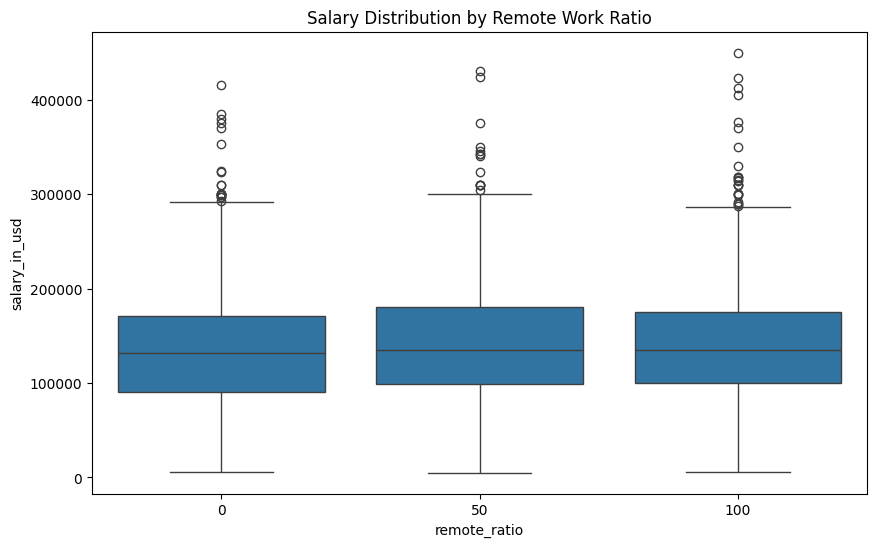

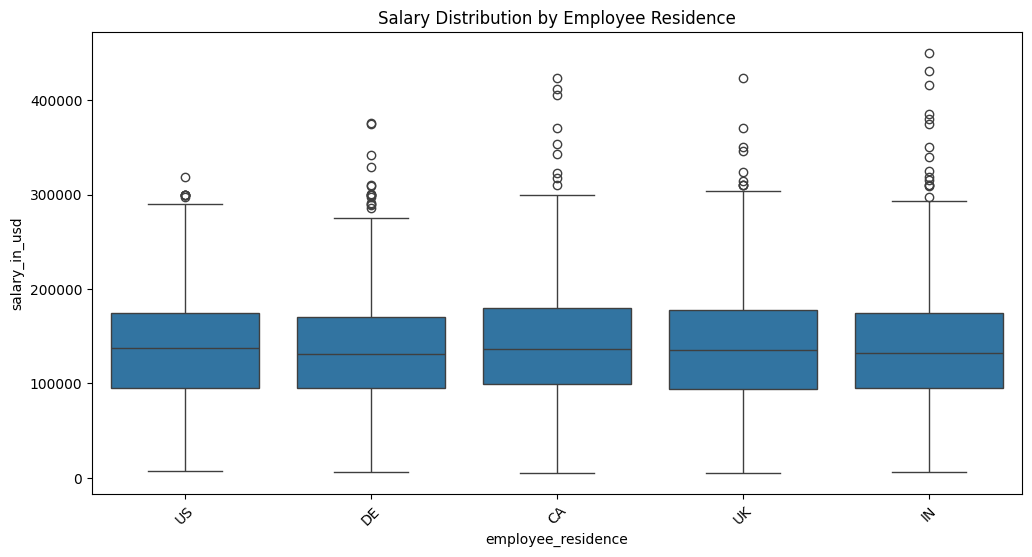

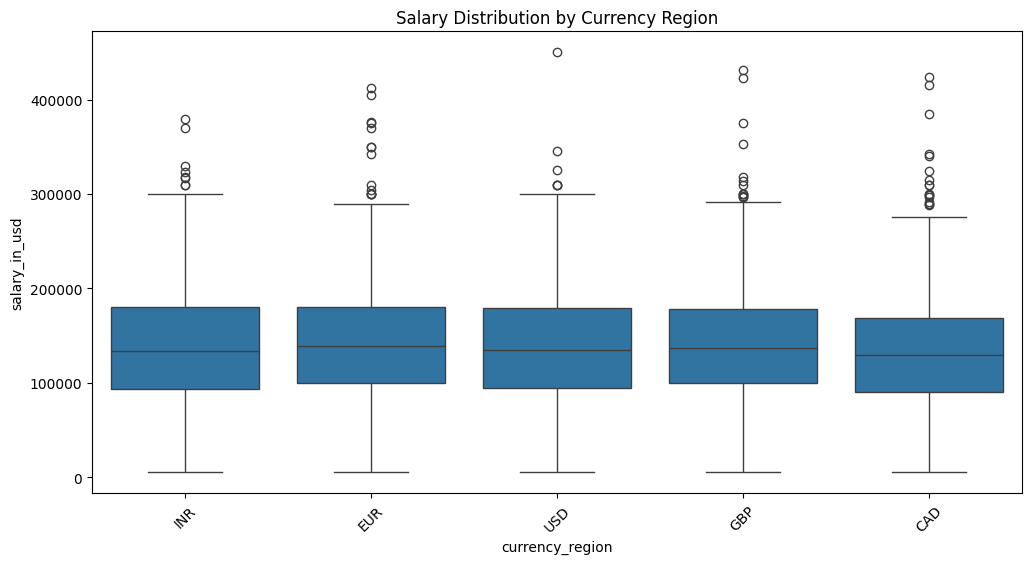


Salary Statistics by Remote Ratio:
               count           mean           std     min       25%       50%  \
remote_ratio                                                                    
0             1299.0  134599.145497  62870.660933  5409.0   90320.0  131300.0   
50            1240.0  140096.448387  62811.062203  5132.0   98951.5  135500.0   
100           1216.0  138168.526316  63423.348832  5409.0  100000.0  135000.0   

                   75%       max  
remote_ratio                      
0             171250.0  416000.0  
50            180000.0  430967.0  
100           175000.0  450000.0  

Top 5 Highest Paying Employee Residences:
employee_residence
CA    140285.035433
UK    138290.217731
US    137337.090418
IN    136500.652406
DE    135334.800543
Name: salary_in_usd, dtype: float64

Salary Statistics by Currency Region:
                          mean    median           std
currency_region                                       
EUR              141171.326059  1387

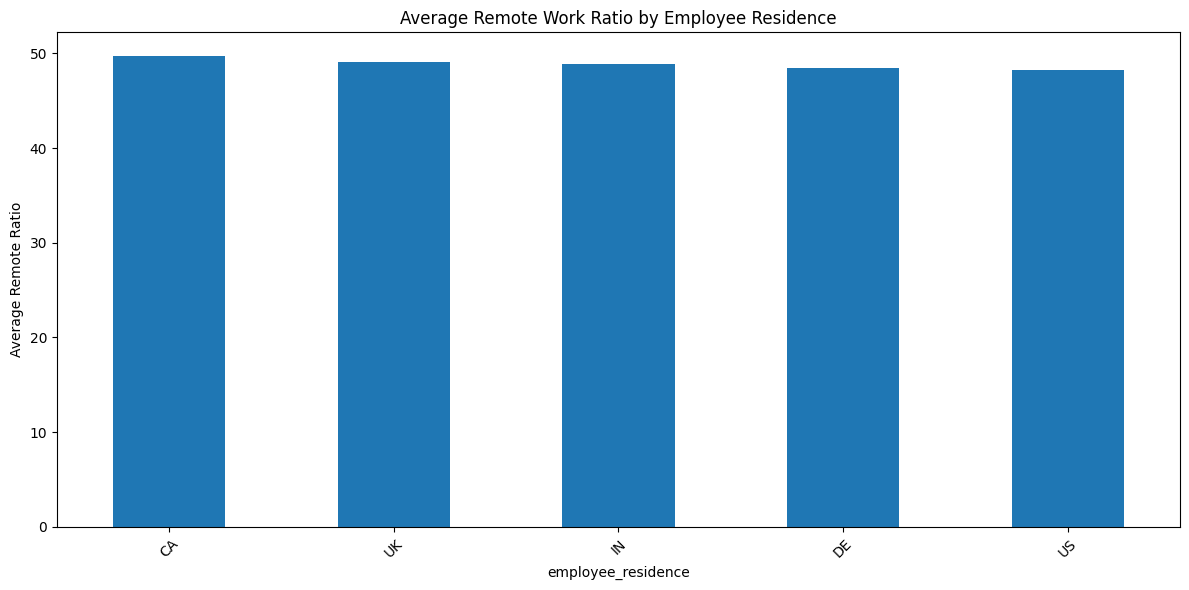

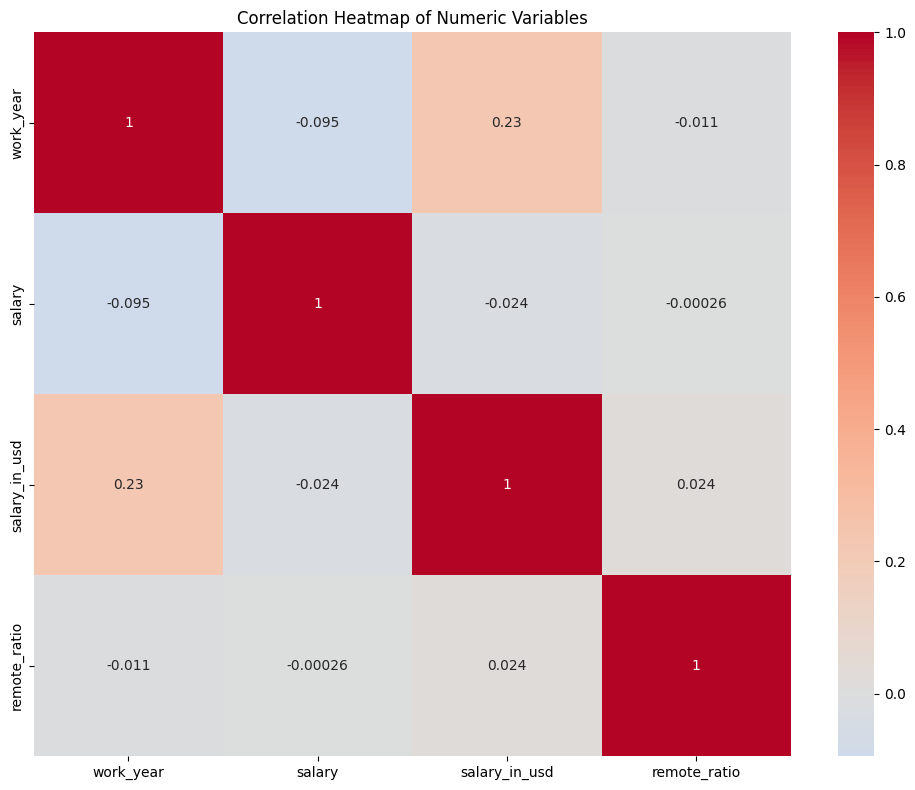

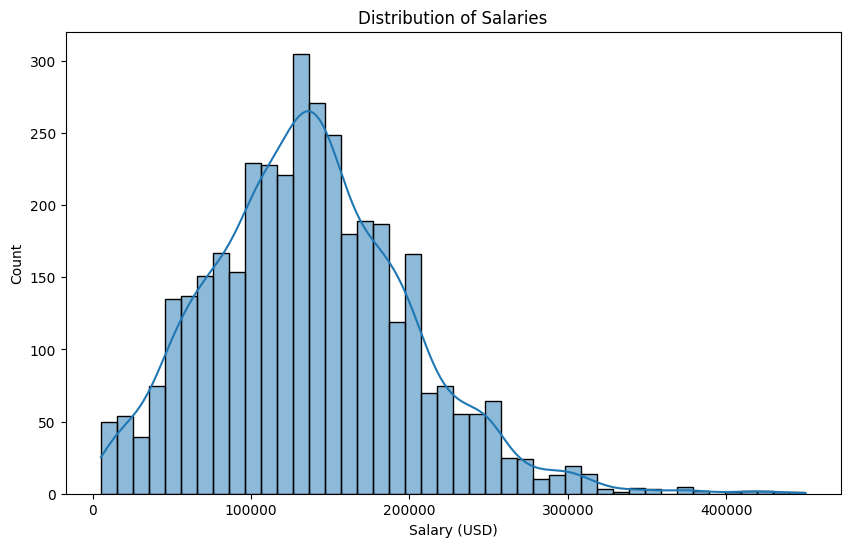


Summary Statistics for Salary:
count      3755.000000
mean     137570.389880
std       63055.625278
min        5132.000000
25%       95000.000000
50%      135000.000000
75%      175000.000000
max      450000.000000
Name: salary_in_usd, dtype: float64


In [132]:
# Ensure salary_in_usd is numeric
df['salary_in_usd'] = pd.to_numeric(df['salary_in_usd'], errors='coerce')

# 1. Analyze the impact of remote_ratio on salary
plt.figure(figsize=(10, 6))
sns.boxplot(x='remote_ratio', y='salary_in_usd', data=df)
plt.title('Salary Distribution by Remote Work Ratio')
plt.show()

# 2. Analyze the impact of employee_residence on salary
plt.figure(figsize=(12, 6))
sns.boxplot(x='employee_residence', y='salary_in_usd', data=df)
plt.title('Salary Distribution by Employee Residence')
plt.xticks(rotation=45)
plt.show()

# 3. Analyze the impact of currency_region on salary
plt.figure(figsize=(12, 6))
sns.boxplot(x='currency_region', y='salary_in_usd', data=df)
plt.title('Salary Distribution by Currency Region')
plt.xticks(rotation=45)
plt.show()

# 4. Descriptive statistics for salary by remote_ratio
remote_stats = df.groupby('remote_ratio')['salary_in_usd'].describe()
print("\nSalary Statistics by Remote Ratio:")
print(remote_stats)

# 5. Top 5 highest paying employee residences
top_residences = df.groupby('employee_residence')['salary_in_usd'].mean().sort_values(ascending=False).head()
print("\nTop 5 Highest Paying Employee Residences:")
print(top_residences)

# 6. Salary differences between currency regions
currency_salary_diff = df.groupby('currency_region')['salary_in_usd'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)
print("\nSalary Statistics by Currency Region:")
print(currency_salary_diff)

# 7. Remote work preference by employee residence
remote_preference = df.groupby('employee_residence')['remote_ratio'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
remote_preference.plot(kind='bar')
plt.title('Average Remote Work Ratio by Employee Residence')
plt.ylabel('Average Remote Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Correlation heatmap (excluding non-numeric columns)
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

# 9. Salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['salary_in_usd'], kde=True)
plt.title('Distribution of Salaries')
plt.xlabel('Salary (USD)')
plt.show()

# 10. Summary statistics for salary
salary_summary = df['salary_in_usd'].describe()
print("\nSummary Statistics for Salary:")
print(salary_summary)